# Section 1
Edge Detection

In [ ]:
!gdown "1VTvvWRgcyb0LjOsQzUsydXa2hKQbs2Zc"

Downloading...
From: https://drive.google.com/uc?id=1VTvvWRgcyb0LjOsQzUsydXa2hKQbs2Zc
To: /content/lab 06 noisy_image.jpg
100% 107k/107k [00:00<00:00, 28.1MB/s]


Given an image with noise, use the following three algorithms for edge detection:

1. Sobel operator

2. Canny algorithm

3. Mar-hildreth algorithm

Display the results respectively.

***(Explaination answer)***

- Q1. Which algorithm is most sensitive to noise?

- Q2. In Canny and Mar-Hildreth algorithms, after the adjusting of kernel size and standard deviation of Gaussian blur, what changes can you observe in the edge detection results? How does Gaussian smoothing affect edge detection?

- Q3. Which algorithm do you think is best for processing high noise images?  Justify your answer.




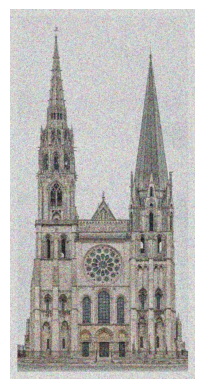

In [ ]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
img= cv.imread('/content/lab 06 noisy_image.jpg')
plt.imshow(img[:,:,::-1])
plt.axis("off")
plt.show()

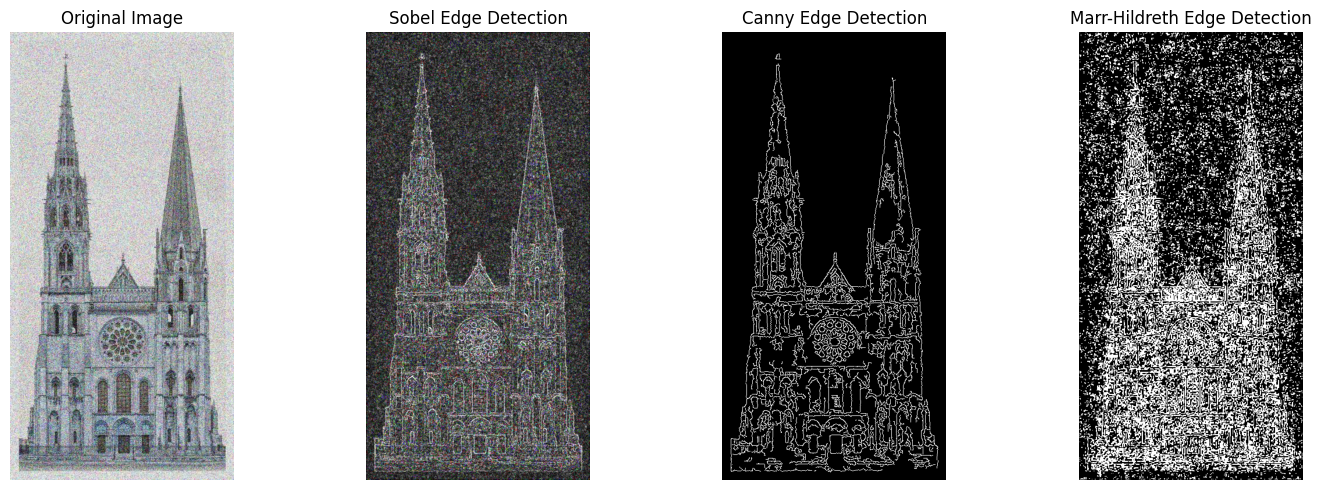

In [ ]:
# Answer your code here

# sobel
x = cv.Sobel(img, cv.CV_16S, 1, 0)
y = cv.Sobel(img, cv.CV_16S, 0, 1)

Scale_absX = cv.convertScaleAbs(x)
Scale_absY = cv.convertScaleAbs(y)

sobel_res = cv.addWeighted(Scale_absX, 0.5, Scale_absY, 0.5, 0)

# Canny edge detection
lowThreshold = 50
highThreshold = 150

filtered_img = cv.GaussianBlur(img, (5, 5), 2)
canny_res = cv.Canny(filtered_img, lowThreshold, highThreshold)

# Marr-Hildreth
blurred = cv.GaussianBlur(img, (5, 5), 1.8)

# Laplacian
laplacian = cv.Laplacian(blurred, cv.CV_64F)

# Detect Zero-Crossings with Thresholding
threshold = 6

zero_crossings = np.zeros_like(laplacian, dtype=np.uint8)

rows, cols, _ = laplacian.shape

for i in range(1, rows - 1):
    for j in range(1, cols - 1):
        # Extract 3×3 Neighborhood
        patch = laplacian[i-1:i+2, j-1:j+2]  # 3x3 patch around the pixel
        # Check for Zero Crossing
        if (patch.min() < -threshold) and (patch.max() > threshold):  # Check zero-crossing with threshold
            zero_crossings[i, j] = 255  # If the above condition is true， mark as an edge

plt.figure(figsize=(15, 5))

plt.subplot(1, 4, 1)
plt.title("Original Image")
plt.imshow(img, cmap='gray')
plt.axis("off")

plt.subplot(1, 4, 2)
plt.title("Sobel Edge Detection")
plt.imshow(sobel_res, cmap='gray')
plt.axis("off")

plt.subplot(1, 4, 3)
plt.title("Canny Edge Detection")
plt.imshow(canny_res, cmap='gray')
plt.axis("off")

plt.subplot(1, 4, 4)
plt.title("Marr-Hildreth Edge Detection")
plt.imshow(zero_crossings, cmap='gray')
plt.axis("off")

plt.tight_layout()
plt.show()

Q1. Which algorithm is most sensitive to noise?


```
Marr-Hildreth algorithm

```


Q2. In Canny and Mar-Hildreth algorithms, after the adjusting of kernel size and standard deviation of Gaussian blur, what changes can you observe in the edge detection results? How does Gaussian smoothing affect edge detection?


```
Adjusting standard deviation of Gaussian ,In Canny Edge Detection is
significant to denoise in edge detection but if it too much the continuity of line be lost.
In Mar-Hildreth  if it too much, will be lead line is more blur.
Kernel size is effect to smooth number in pixel of image before take first derivative(sobel) or
second derivative(lapacian), if it big, it's can denoise but too much will lost information of
image or make line is blur.
```


Q3. Which algorithm do you think is best for processing high noise images? Justify your answer.


```
I think Canny edge detection is take best performance because in result there
have no noise and the line have great continuity and from trying it easy to
denoise but another have too take long or can't adjust to use.
```



# Section 2


In [ ]:
!gdown "1QAG2i9RVuArct8JseVD0Oq8Hsxz3spRd"

Downloading...
From: https://drive.google.com/uc?id=1QAG2i9RVuArct8JseVD0Oq8Hsxz3spRd
To: /content/lab 06 church.jpg
100% 209k/209k [00:00<00:00, 64.2MB/s]


Given an image, use the following three algorithms for edge detection:

1. Sobel operator

2. Canny algorithm

3. Mar-hildreth algorithm

Display the results respectively.

***(Explaination answer)***

- Q1. Which algorithm produces the most detailed edges?
- Q2. Which algorithm provides the most accurate and continuous edges? Justify your reasoning.
- Q3. Based on your observations, which algorithm do you think is the best for general image processing tasks?




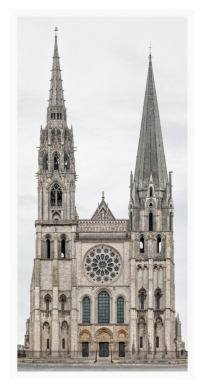

In [ ]:
img= cv.imread('/content/lab 06 church.jpg')
plt.imshow(img[:,:,::-1])
plt.axis("off")
plt.show()

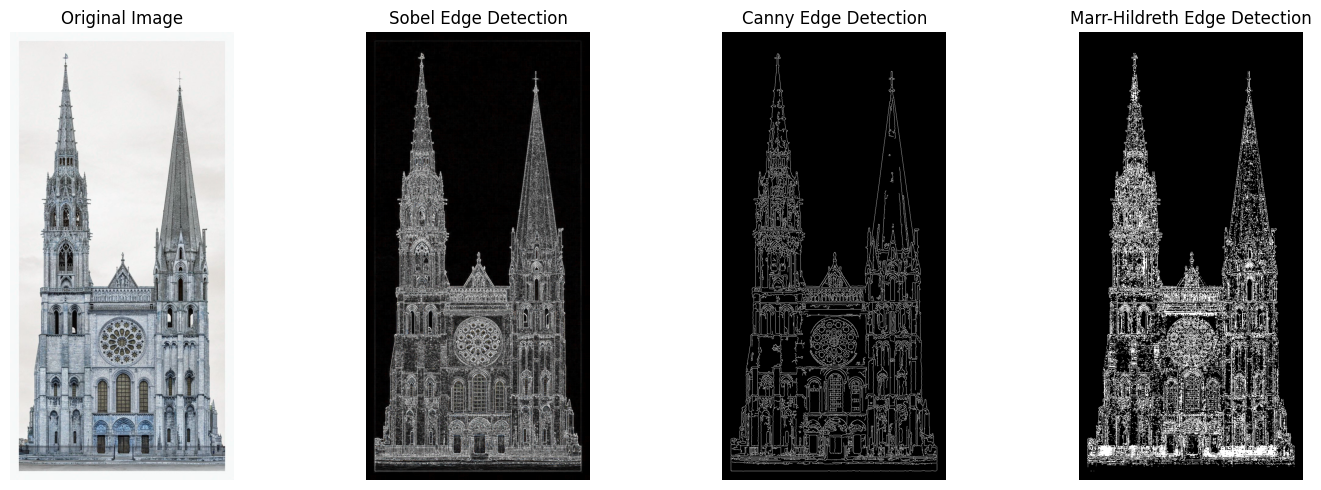

In [ ]:
# Answer your code here
# sobel
x = cv.Sobel(img, cv.CV_16S, 1, 0)
y = cv.Sobel(img, cv.CV_16S, 0, 1)

Scale_absX = cv.convertScaleAbs(x)
Scale_absY = cv.convertScaleAbs(y)

sobel_res = cv.addWeighted(Scale_absX, 0.5, Scale_absY, 0.5, 0)

# Canny edge detection
lowThreshold = 50
highThreshold = 150

filtered_img = cv.GaussianBlur(img, (5, 5), 2)
canny_res = cv.Canny(filtered_img, lowThreshold, highThreshold)

# Marr-Hildreth
blurred = cv.GaussianBlur(img, (5, 5), 1.8)

# Laplacian
laplacian = cv.Laplacian(blurred, cv.CV_64F)

# Detect Zero-Crossings with Thresholding
threshold = 6

zero_crossings = np.zeros_like(laplacian, dtype=np.uint8)

rows, cols, _ = laplacian.shape

for i in range(1, rows - 1):
    for j in range(1, cols - 1):
        # Extract 3×3 Neighborhood
        patch = laplacian[i-1:i+2, j-1:j+2]  # 3x3 patch around the pixel
        # Check for Zero Crossing
        if (patch.min() < -threshold) and (patch.max() > threshold):  # Check zero-crossing with threshold
            zero_crossings[i, j] = 255  # If the above condition is true， mark as an edge

plt.figure(figsize=(15, 5))

plt.subplot(1, 4, 1)
plt.title("Original Image")
plt.imshow(img, cmap='gray')
plt.axis("off")

plt.subplot(1, 4, 2)
plt.title("Sobel Edge Detection")
plt.imshow(sobel_res, cmap='gray')
plt.axis("off")

plt.subplot(1, 4, 3)
plt.title("Canny Edge Detection")
plt.imshow(canny_res, cmap='gray')
plt.axis("off")

plt.subplot(1, 4, 4)
plt.title("Marr-Hildreth Edge Detection")
plt.imshow(zero_crossings, cmap='gray')
plt.axis("off")

plt.tight_layout()
plt.show()

Q1. Which algorithm produces the most detailed edges?


```
Canny Edge Detection
```


Q2. Which algorithm provides the most accurate and continuous edges? Justify your reasoning.


```
Canny Edge Detection for this image, it look like no continuity and have not much detaild but i think for the edge detection
we should select method is return something it like 'line' but in sobel it take much detaild but line is so blurly
and it look continuity by blurly line.
```


Q3. Based on your observations, which algorithm do you think is the best for general image processing tasks?



```
Canny Edge Detection
```




# Section 3

**Lane Detection**

Lane detection is one of the basic concepts when trying to understand how self-driving cars work.Hough transform can help to detect straight lines in the region of interest.

**Q1 : In this section you will deal with 2 image of lane data and try to show result of lane detection.**

**Tools**
* Edge Detection Ex. Canny.
* Line Detection Ex. Hough Transform Technique.
* Other tools you can also use to apply in your code.

> This is 2 image data for using in your code of this section.



In [ ]:
# Road1 gray-scale image (name:lane.jpg)
!gdown "1Y4ihYnHmxBKSK5SZKFrdKLW_-hGGSvFZ"

Downloading...
From: https://drive.google.com/uc?id=1Y4ihYnHmxBKSK5SZKFrdKLW_-hGGSvFZ
To: /content/lane.jpg
100% 35.2k/35.2k [00:00<00:00, 50.9MB/s]


In [ ]:
# Road2 color image (name:lane2.jpg)
!gdown "1BWa86A6oSJTXOFPiTzb0g2KvCbBcqeuF"

Downloading...
From: https://drive.google.com/uc?id=1BWa86A6oSJTXOFPiTzb0g2KvCbBcqeuF
To: /content/lane2.jpg
100% 776k/776k [00:00<00:00, 88.3MB/s]


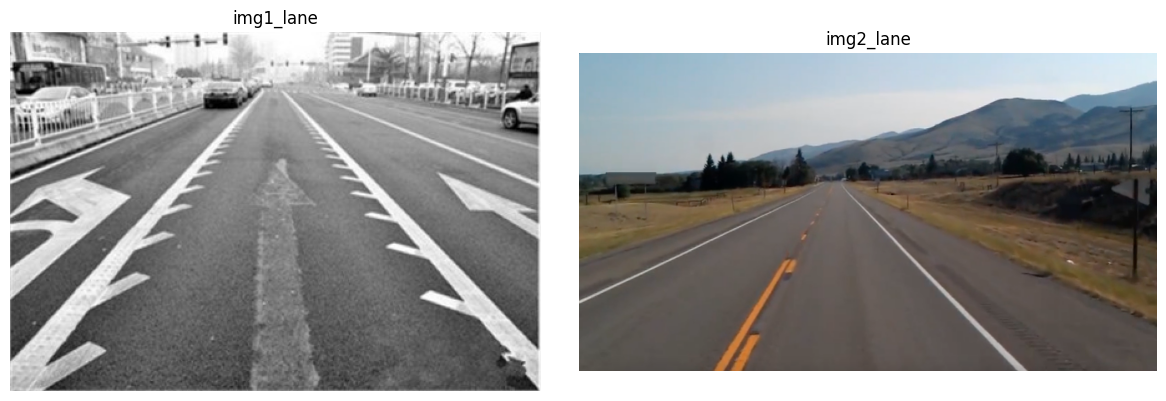

In [ ]:
img1_lane= cv.imread('/content/lane.jpg')
img2_lane= cv.imread('/content/lane2.jpg')

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.imshow(img1_lane[:,:,::-1], cmap='brg', vmin=0, vmax=1)
plt.title('img1_lane')
plt.axis('off')

# Step 9: results of dest diliated
plt.subplot(1, 2, 2)
plt.imshow(img2_lane[:,:,::-1], cmap='brg', vmin=0, vmax=1)
plt.title('img2_lane')
plt.axis('off')

plt.tight_layout()
plt.show()


In [ ]:
#Add your code here!

import cv2 as cv
import matplotlib.pyplot as plt

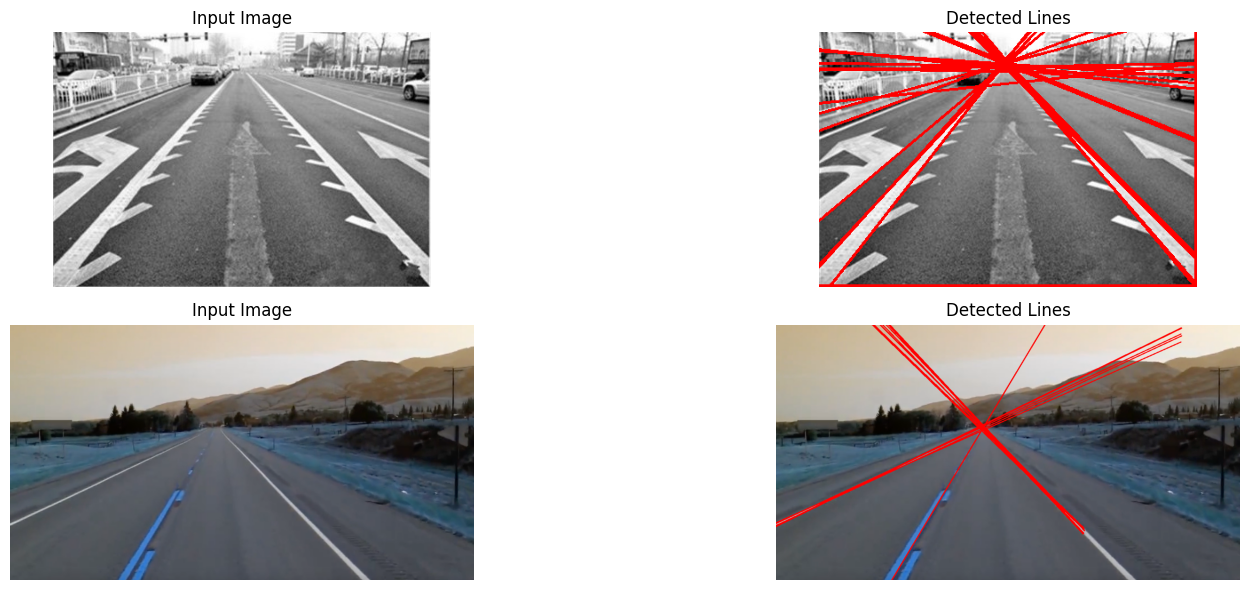

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Preprocessing (Edge Detection)
edges_1 = cv.Canny(img1_lane, threshold1=225, threshold2=200, apertureSize=3)
edges_2 = cv.Canny(img2_lane, threshold1=225, threshold2=200, apertureSize=3)

# Step 2: Hough Transform for Line Detection
lines_1 = cv.HoughLines(edges_1, rho=1, theta=np.pi/180, threshold=120)
lines_2 = cv.HoughLines(edges_2, rho=1, theta=np.pi/180, threshold=120)

# Step 3: Draw the detected lines on the original image
output_image_1 = img1_lane.copy()

if lines_1 is not None:
    for line in lines_1:
        rho, theta = line[0]
        a = np.cos(theta)
        b = np.sin(theta)
        x0 = a * rho
        y0 = b * rho
        x1 = int(x0 + 1000 * (-b))
        y1 = int(y0 + 1000 * (a))
        x2 = int(x0 - 1000 * (-b))
        y2 = int(y0 - 1000 * (a))
        cv.line(output_image_1, (x1, y1), (x2, y2), (0, 0, 255), 2)

output_image_2 = img2_lane[:,:,::-1].copy()

if lines_2 is not None:
    for line in lines_2:
        rho, theta = line[0]
        a = np.cos(theta)
        b = np.sin(theta)
        x0 = a * rho
        y0 = b * rho
        x1 = int(x0 + 1000 * (-b))
        y1 = int(y0 + 1000 * (a))
        x2 = int(x0 - 1000 * (-b))
        y2 = int(y0 - 1000 * (a))
        cv.line(output_image_2, (x1, y1), (x2, y2), (0, 0, 255), 2)

# Step 4: Visualization
plt.figure(figsize=(18, 6))
plt.subplot(2, 2, 1)
plt.title("Input Image")
plt.imshow(img1_lane, cmap='gray')
plt.axis("off")

plt.subplot(2, 2, 2)
plt.title("Detected Lines")
plt.imshow(cv.cvtColor(output_image_1, cv.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(2, 2, 3)
plt.title("Input Image")
plt.imshow(img2_lane)
plt.axis("off")

plt.subplot(2, 2, 4)
plt.title("Detected Lines")
plt.imshow(cv.cvtColor(output_image_2,cv.COLOR_BGR2RGB))
plt.axis("off")

plt.tight_layout()
plt.show()

**Q2 : How are these two images from the lane dataset obstacles for you when implementing the code to detect lane results?**

***(Explaination answer)***

Ans. Canny Edge Detection have best preformance for detect edge and use hough transform for find the straight line if threshold too low count of line may increase.